In [1]:
# ---- Reproducibility
import random
import torch

#seed = 1234
#random.seed(seed)
#torch.manual_seed(seed)
#if torch.cuda.is_available():
#    torch.cuda.manual_seed_all(seed)


In [2]:


# ---- Parameters
n, p = 50, 40
noise_std = 0.1

# (Optional) choose device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Data generation (PyTorch)
# Use float64 to mirror NumPy defaults
u = torch.rand(n, dtype=torch.float64, device=device)          # length n
v = torch.rand(p, dtype=torch.float64, device=device)          # length p

# Rank-1 matrix via outer product
rank_1_matrix = torch.outer(u, v)                              # (n, p)

# Homoscedastic Gaussian noise
noise = noise_std * torch.randn(n, p, dtype=torch.float64, device=device)

noisy_matrix = rank_1_matrix + noise

# ---- Print (move to CPU for readability if needed)
print("Rank-1 Matrix (Outer Product):")
print(rank_1_matrix.cpu().numpy())

print("\nNoisy Matrix (with Homoscedastic Noise):")
print(noisy_matrix.cpu().numpy())


Rank-1 Matrix (Outer Product):
[[0.4093134  0.08800456 0.23144586 ... 0.24109522 0.40332002 0.42885773]
 [0.58177588 0.12508491 0.3289646  ... 0.34267968 0.57325723 0.60955515]
 [0.71677674 0.15411081 0.4053007  ... 0.42219836 0.70628133 0.75100217]
 ...
 [0.65607208 0.14105899 0.37097531 ... 0.38644189 0.64646554 0.68739892]
 [0.51004629 0.10966267 0.28840517 ... 0.30042926 0.50257794 0.53440053]
 [0.48899634 0.10513682 0.2765025  ... 0.28803035 0.48183621 0.51234547]]

Noisy Matrix (with Homoscedastic Noise):
[[0.54026511 0.03028463 0.21504047 ... 0.23443716 0.51174141 0.44406006]
 [0.53289702 0.03618885 0.34076911 ... 0.19638278 0.47640111 0.36118672]
 [0.67341029 0.22096367 0.32137569 ... 0.3207911  0.76262147 0.72368351]
 ...
 [0.5961728  0.16978227 0.30608565 ... 0.48579879 0.66476839 0.60642164]
 [0.50837852 0.07668765 0.22015694 ... 0.2550499  0.47499133 0.39391788]
 [0.43265154 0.07746084 0.29638136 ... 0.2350104  0.30494839 0.54585757]]


In [3]:
import sys
import os
import matplotlib.pyplot as plt
from cebmf_torch import cEBMF

In [4]:
mycebmf=  cEBMF(data= noisy_matrix, prior_F="laplace",
                prior_L="laplace") 

 

In [5]:
mycebmf.initialise_factors()
print(mycebmf.L[:,1])

print(mycebmf.F[:,1])

tensor([ 0.4056, -0.0910, -0.3070, -0.0357,  0.1284,  0.1372, -0.1120, -0.3354,
         0.2647,  0.0247,  0.0327, -0.2571,  0.2977,  0.2384, -0.0125,  0.0145,
         0.0129,  0.0682, -0.2352,  0.1281, -0.0584,  0.1620,  0.2624, -0.0399,
        -0.0334,  0.0093,  0.0807,  0.0336, -0.2573,  0.1471, -0.3340,  0.0209,
         0.0340, -0.1250,  0.2013, -0.3049, -0.0378,  0.0023,  0.2644,  0.1327,
         0.0039, -0.1959,  0.0491,  0.1037, -0.4303,  0.2643,  0.1434,  0.0633,
        -0.0785, -0.1883])
tensor([ 0.1109, -0.3580, -0.1867, -0.1518, -0.0709,  0.0725, -0.2790, -0.0020,
        -0.1890,  0.0835,  0.2879,  0.0735, -0.0669, -0.0485, -0.0963,  0.0608,
         0.0177,  0.1758,  0.0501, -0.2535,  0.0292,  0.0231,  0.0371,  0.0159,
        -0.0762, -0.1117, -0.2202, -0.0021,  0.0615,  0.2275,  0.0507,  0.2911,
         0.1011,  0.0883, -0.2110,  0.0969, -0.2617,  0.0284,  0.2349,  0.2358])


In [6]:
mycebmf.L @  mycebmf.F.T

tensor([[ 0.3975, -0.1192,  0.1475,  ...,  0.1947,  0.4492,  0.4286],
        [ 0.5392,  0.0283,  0.3742,  ...,  0.2519,  0.5710,  0.5314],
        [ 0.6611,  0.2145,  0.4434,  ...,  0.4250,  0.6546,  0.6453],
        ...,
        [ 0.6767,  0.0744,  0.3612,  ...,  0.4007,  0.6991,  0.6845],
        [ 0.5008,  0.0443,  0.3555,  ...,  0.2557,  0.5101,  0.4749],
        [ 0.4693,  0.1714,  0.2898,  ...,  0.3239,  0.4530,  0.4552]])

In [7]:

k=0
f_o=mycebmf.F[:,k]
l_o=mycebmf.L[:,k]
R= noisy_matrix- mycebmf.L@mycebmf.F.T
Rk= mycebmf._partial_residual_masked(k)

print(Rk)

 

tensor([[ 0.4998,  0.1891,  0.2740,  ...,  0.2439,  0.4340,  0.3757],
        [ 0.5586,  0.0706,  0.2932,  ...,  0.2675,  0.4931,  0.3998],
        [ 0.7022,  0.0830,  0.2769,  ...,  0.2903,  0.8258,  0.7746],
        ...,
        [ 0.5831,  0.1690,  0.3286,  ...,  0.4646,  0.6561,  0.5916],
        [ 0.5310,  0.0905,  0.1672,  ...,  0.2986,  0.5094,  0.4471],
        [ 0.4423, -0.0407,  0.2835,  ...,  0.1850,  0.3503,  0.5740]])


In [8]:
import torch

k = 0
Y0   = mycebmf.Y0
M    = mycebmf.mask
L    = mycebmf.L
F    = mycebmf.F

# Clone these to avoid view aliasing issues
l_old = L[:, k].clone()
f_old = F[:, k].clone()

# Baseline residual (masked)
recon = L @ F.T
R     = (Y0 - recon) * M

# Partial residual excluding factor k
Rk = (Y0 - (recon - torch.outer(l_old, f_old))) * M

# 1) First identity: Rk = R + l_old f_old^T  (masked)
print(torch.allclose(Rk, R + torch.outer(l_old, f_old) * M, atol=1e-7))

# Mutate L[:,k] --> l_new
L[:, k] = l_old + 1.0
l_new = L[:, k]  # (this is fine; we already saved l_old above)

# New residual (recompute from scratch, masked)
recon_new = L @ F.T
R_new     = (Y0 - recon_new) * M

# 2) Second identity: R_new = Rk - l_new f_old^T  (masked)
print(torch.allclose(R_new, Rk - torch.outer(l_new, f_old) * M, atol=1e-7))


True
True


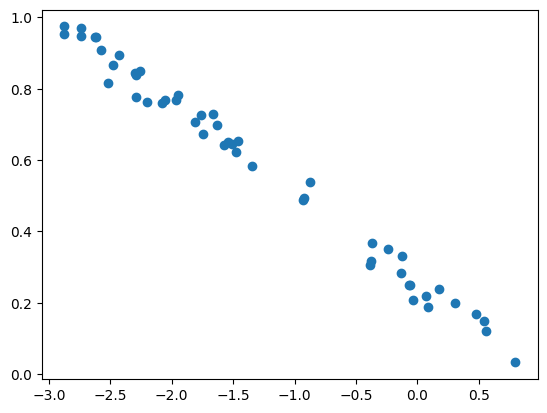

In [9]:
plt.scatter( mycebmf.L[:,0],u)

In [10]:
mycebmf.iter_once()
mycebmf._update_fitted_value()
import numpy as np
K=0
mycebmf.Y_fit 

tensor([[ 0.3860, -0.0783,  0.1598,  ...,  0.1960,  0.4294,  0.4139],
        [ 0.5525,  0.0470,  0.3482,  ...,  0.2868,  0.5783,  0.5478],
        [ 0.6678,  0.1689,  0.4315,  ...,  0.4100,  0.6727,  0.6569],
        ...,
        [ 0.6681,  0.0711,  0.3730,  ...,  0.3870,  0.6939,  0.6763],
        [ 0.5128,  0.0518,  0.3257,  ...,  0.2718,  0.5263,  0.4984],
        [ 0.4697,  0.1200,  0.2882,  ...,  0.2978,  0.4707,  0.4646]])

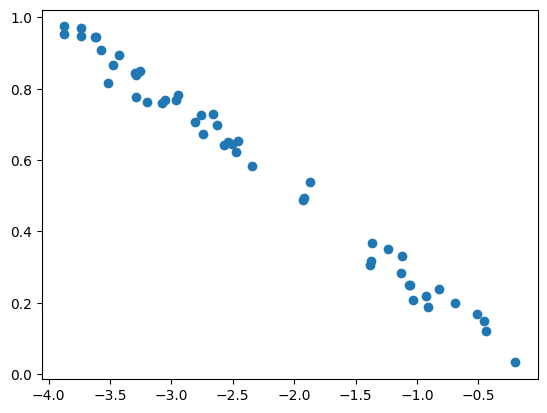

In [11]:
plt.scatter( mycebmf.L[:,0],u)

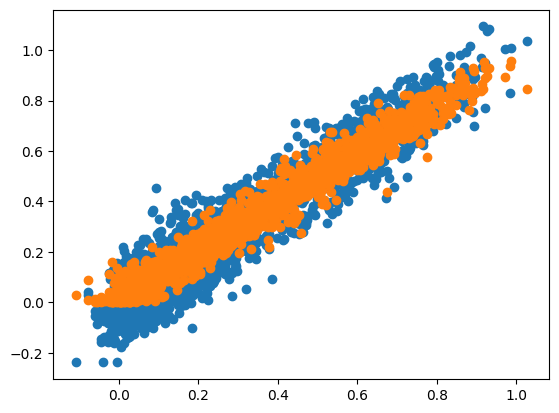

In [12]:
mycebmf.iter_once()  
plt.scatter(mycebmf.Y_fit, noisy_matrix)
 
plt.scatter(mycebmf.Y_fit, rank_1_matrix)

In [13]:
mycebmf=  cEBMF(data= noisy_matrix, prior_F="laplace",
                prior_L="laplace") 
mycebmf.initialise_factors()

mycebmf.fit()

CEBMFResult(L=tensor([[-1.8715e+00,  7.6478e-06,  2.3883e-06,  2.6725e-06],
        [-2.9640e+00, -6.9752e-06,  2.3852e-06,  2.9845e-07],
        [-3.6212e+00,  1.2469e-05,  2.3844e-06,  2.6709e-06],
        [-2.8154e+00, -2.0980e-06, -6.0418e-06,  3.0970e-07],
        [-8.1900e-01,  2.7769e-06, -1.8353e-06, -2.0233e-06],
        [-3.8791e+00,  7.6304e-06,  1.0824e-05,  2.6539e-06],
        [-1.9329e+00, -1.1857e-05,  2.3787e-06,  3.1131e-07],
        [-3.3004e+00, -7.0355e-06, -1.8365e-06,  2.9762e-07],
        [-2.5790e+00,  2.8213e-06, -1.8316e-06,  3.2420e-07],
        [-3.2951e+00, -2.1349e-06,  6.6098e-06,  3.0730e-07],
        [-1.1222e+00, -2.1187e-06,  6.6017e-06, -2.0506e-06],
        [-2.5424e+00,  2.7304e-06,  2.3910e-06,  2.9201e-07],
        [-4.3324e-01, -6.9848e-06,  6.5946e-06, -2.0346e-06],
        [-2.6355e+00, -6.9654e-06, -1.8287e-06, -2.0490e-06],
        [-1.0318e+00, -2.0992e-06,  2.3806e-06, -2.0546e-06],
        [-3.6244e+00, -2.0917e-06,  6.6003e-06, -2.0362e

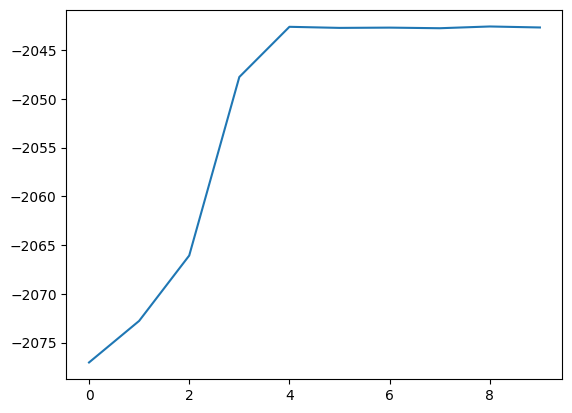

In [14]:
mycebmf.iter_once()  
plt.plot(mycebmf.obj)

In [ ]:
results =[]
for i in range(50):
    # Parameters
    n, p = 50, 40
    noise_std = 0.1

# (Optional) choose device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Data generation (PyTorch)
# Use float64 to mirror NumPy defaults
    u = torch.rand(n, dtype=torch.float64, device=device)          # length n
    v = torch.rand(p, dtype=torch.float64, device=device)          # length p

# Rank-1 matrix via outer product
    rank_1_matrix = torch.outer(u, v)                              # (n, p)

# Homoscedastic Gaussian noise
    noise = noise_std * torch.randn(n, p, dtype=torch.float64, device=device)

    noisy_matrix = rank_1_matrix + noise

 
# Add homoscedastic Gaussian noise (constant variance across the matrix)
    mycebmf=  cEBMF(data= noisy_matrix, prior_F="laplace",
                      prior_L="laplace") 
    mycebmf.initialise_factors()

    mycebmf.fit()
    
    mycebmf._update_fitted_value()
    
    rr = torch.sqrt(torch.mean(mycebmf.Y_fit- rank_1_matrix)**2)
    results.append( rr)
    res= np.asarray(results)
    print(np.mean(res ))
    
 

In [ ]:
i

49

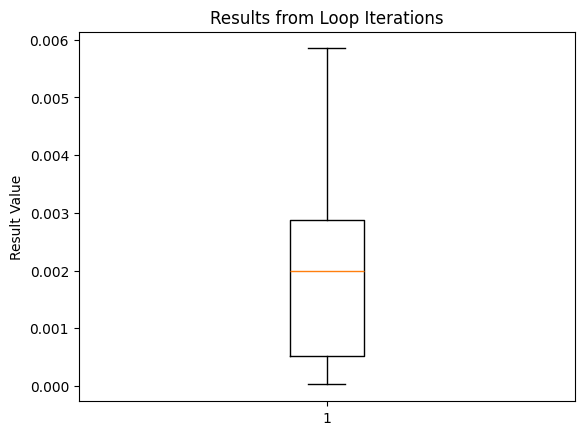

In [ ]:
plt.boxplot(results   )
plt.title("Results from Loop Iterations")
plt.ylabel("Result Value")
plt.show()

In [ ]:
res= np.asarray(results )
np.mean(res )

np.float64(0.00197172027171406)

In [ ]:
np.sqrt(np.var(res ))

np.float64(0.001574784383880469)

In [ ]:
#0.0022667179506868484